#  Data Cleaning & Preparation
### Online Shopping Database

**Purpose:** Clean, validate, and prepare the main tables for the next stage of the project (SQL / analysis).

### Cleaning requirements
- **Customers:** clean/standardize Email and Gender.
- **Employees:** clean/standardize Email, Salary, and Gender.
- **Orders / Sales:** calculate **Total Amount** from order items and attach it to the Orders table.
- **Products:** clean Price and Stock Quantity, inspect and treat outliers, and keep Product information consistent.
- **Quality checks:** verify data types, missing values, duplicates, and the results of each transformation.

> **Important:** The notebook keeps the original data in separate DataFrames where possible and creates cleaned versions before export. This makes the cleaning process easier to audit and reproduce.


## 1. Setup & Load the Workbook

We start by importing the required libraries and reading the Excel workbook.  
The workbook contains the source tables used throughout the cleaning process.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

file_path = "Clean_Project (3).xlsx"

xls = pd.ExcelFile(file_path)

print("Workbook loaded successfully.")
print("Number of sheets:", len(xls.sheet_names))
print("\nSheet Names:")
print("\n".join(xls.sheet_names))


Workbook loaded successfully.
Number of sheets: 18

Sheet Names:
online_shopping_db_branches
online_shopping_db_categories
Clean_online_shopping_db_custom
online_shopping_db_employees
online_shopping_db_order_activi
online_shopping_db_order_items
online_shopping_db_orders
Clean_online_shopping_db_produc
Sheet9
Sheet8
Sheet7
Sheet6
Sheet2
online_shopping_db_deliveries
Sheet5
Sheet4
Sheet3
Sheet1


## 2. Initial Data Structure Review

Before changing anything, we inspect the available sheets and their columns.  
This helps confirm the table structure and identify which sheets are relevant to the cleaning requirements.


In [9]:
for sheet in xls.sheet_names:
    temp_df = pd.read_excel(xls, sheet_name=sheet)
    print(f"\n===== {sheet} =====")
    print("Rows:", len(temp_df))
    print("Columns:", temp_df.columns.tolist())



===== online_shopping_db_branches =====
Rows: 24
Columns: ['Branch_ID', 'Branch_Name', 'Location', 'Phone_Number']

===== online_shopping_db_categories =====
Rows: 20
Columns: ['Category_ID', 'Category_Name']

===== Clean_online_shopping_db_custom =====
Rows: 3000
Columns: ['Customer_ID', 'Customer_Name', 'Email', 'Phone', 'Gender', 'City', 'Registration_Date']

===== online_shopping_db_employees =====
Rows: 3000
Columns: ['Employee_ID', 'Employee_Name', 'Job_Title', 'Salary', 'Phone_Number', 'Email', 'Gender', 'BranchID']

===== online_shopping_db_order_activi =====
Rows: 3000
Columns: ['Activity_ID', 'Activity_Type', 'Activity_Date', 'Status', 'OrderId', 'EmployeeID']

===== online_shopping_db_order_items =====
Rows: 3000
Columns: ['OrderID', 'ProductID', 'Quantity', 'Selling_Price']

===== online_shopping_db_orders =====
Rows: 3000
Columns: ['Order_ID', 'Order_Date', 'Order_Status', 'Payment_Method', 'CustomerId', 'BranchId', 'DeliveryId']

===== Clean_online_shopping_db_produc ===

## 3. Orders & Sales — Calculate Total Amount

The `order_items` table contains:
- `OrderID`
- `ProductID`
- `Quantity`
- `Selling_Price`

For each order item:

**Total Amount = Quantity × Selling Price**

Then we aggregate the item-level amounts by `OrderID` and merge the result into the Orders table.


In [ ]:
df_order_items = pd.read_excel(
    xls,
    sheet_name="online_shopping_db_order_items"
)

df_order_items["Total_Amount"] = (
    df_order_items["Quantity"] * df_order_items["Selling_Price"]
)

print("Order items shape:", df_order_items.shape)
display(df_order_items.head())


Order items shape: (3000, 5)


,OrderID,ProductID,Quantity,Selling_Price,Total_Amount
0,1,136,48,409,19632
1,2,1805,44,225,9900
2,3,2657,26,63,1638
3,4,2914,5,275,1375
4,5,1310,1,200,200


In [ ]:
order_totals = (
    df_order_items
    .groupby("OrderID", as_index=False)["Total_Amount"]
    .sum()
)

df_orders = pd.read_excel(
    xls,
    sheet_name="online_shopping_db_orders"
)

df_orders = df_orders.merge(
    order_totals,
    left_on="Order_ID",
    right_on="OrderID",
    how="left"
).drop(columns="OrderID")

print("Orders shape:", df_orders.shape)
display(df_orders.head())


Orders shape: (3000, 8)


,Order_ID,Order_Date,Order_Status,Payment_Method,CustomerId,BranchId,DeliveryId,Total_Amount
0,1,2026-03-10,Completed,Paypal,2594,2,630,19632
1,2,2026-03-03,Pending,Cash,2072,11,1921,9900
2,3,2026-03-05,Cancelled,Cash,194,1,154,1638
3,4,2026-01-29,Pending,Credit Card,893,14,1688,1375
4,5,2026-01-23,Pending,Cash,2565,12,680,200


In [ ]:
print("Missing Total Amount values:", df_orders["Total_Amount"].isna().sum())
print("\nTotal Amount summary:")
display(df_orders["Total_Amount"].describe())

print("\nOrder item numeric validation:")
display(
    df_order_items[["Quantity", "Selling_Price", "Total_Amount"]]
    .describe()
)


Missing Total Amount values: 0

Total Amount summary:


count     3000.000000
mean      2234.066667
std       3699.330850
min         10.000000
25%        369.750000
50%        870.000000
75%       2105.000000
max      23904.000000
Name: Total_Amount, dtype: float64


Order item numeric validation:


,Quantity,Selling_Price,Total_Amount
count,3000.000000,3000.000000,3000.000000
mean,9.003000,251.815667,2234.066667
std,12.140873,141.622112,3699.330850
min,1.000000,10.000000,10.000000
25%,2.000000,128.750000,369.750000
50%,4.000000,248.000000,870.000000
75%,9.000000,373.000000,2105.000000
max,50.000000,500.000000,23904.000000


### Sales calculation result

The `Total_Amount` column is calculated from the transaction-level quantity and selling price, then aggregated at order level.

This avoids manually entering totals and keeps the calculation reproducible.


## 4. Customers — Email & Gender Cleaning

### Email
We standardize email values by:
1. Removing leading/trailing spaces.
2. Converting valid emails to lowercase.
3. Replacing clearly invalid values (for example, values containing `INVALID_EMAIL` or missing `@`) with a consistent generated placeholder based on the customer's name.

### Gender
The dataset contains gender values, and the cleaning step also checks the first name against the provided name mapping used in the project.

> **Assumption:** Gender inference from first names is a project-data rule, not a universally reliable way to determine a person's gender. The rule is documented here so the transformation is transparent.


In [12]:
customers = pd.read_excel(
    xls,
    sheet_name="Clean_online_shopping_db_custom"
)

print("Customers shape:", customers.shape)
display(customers.head(20))


Customers shape: (3000, 7)


,Customer_ID,Customer_Name,Email,Phone,Gender,City,Registration_Date
0,1,Mariam Ibrahim,mariam1@mail.com,1583174450,Female,Asyut,2026-06-25
1,2,Omar Ali,omar2@mail.com,1568917646,Male,Giza,2026-11-18
2,3,Omar Mostafa,omar3@mail.com,1540987853,Male,Sohag,2024-11-06
3,4,Omar Elsayed,omar4@mail.com,1578189164,Male,Cairo,2024-02-20
4,5,Mona Hassan,mona5@mail.com,1544720565,Female,Sohag,2024-11-01
5,6,Mona Ali,mona6@mail.com,1570842090,Male,Cairo,2025-09-18
6,7,Mona Ali,INVALID_EMAIL,1548097468,Male,Cairo,2025-11-11
7,8,Khaled Ali,INVALID_EMAIL,1587178553,Male,Sohag,2026-08-28
8,9,Ahmed Elsayed,ahmed9@mail.com,1566902638,Female,Tanta,2026-12-14
9,10,Omar Gaber,omar10@mail.com,1587000605,Female,Cairo,2026-02-20


In [ ]:
def clean_customer_email(row):
    email = str(row["Email"]).strip().lower()

    if (
        email == "nan"
        or "invalid_email" in email
        or "@" not in email
    ):
        clean_name = re.sub(r"\s+", "", str(row["Customer_Name"])).lower()
        return f"{clean_name}@mail.com"

    return email

customers["Email"] = customers.apply(clean_customer_email, axis=1)

name_parts = customers["Customer_Name"].astype(str).str.split(
    " ", n=1, expand=True
)

customers["First_Name"] = name_parts[0]
customers["Last_Name"] = name_parts[1] if name_parts.shape[1] > 1 else ""

female_names = {"Mariam", "Mona", "Nour", "Fatima", "Sara"}

customers["Gender"] = customers["First_Name"].apply(
    lambda name: "Female" if name in female_names else "Male"
)

customers["Customer_Name"] = (
    customers["First_Name"].fillna("") + " " +
    customers["Last_Name"].fillna("")
).str.strip()

customers.drop(columns=["First_Name", "Last_Name"], inplace=True)

display(customers[["Customer_Name", "Email", "Gender"]].head(20))


,Customer_Name,Email,Gender
0,Mariam Ibrahim,mariam1@mail.com,Female
1,Omar Ali,omar2@mail.com,Male
2,Omar Mostafa,omar3@mail.com,Male
3,Omar Elsayed,omar4@mail.com,Male
4,Mona Hassan,mona5@mail.com,Female
5,Mona Ali,mona6@mail.com,Female
6,Mona Ali,monaali@mail.com,Female
7,Khaled Ali,khaledali@mail.com,Male
8,Ahmed Elsayed,ahmed9@mail.com,Male
9,Omar Gaber,omar10@mail.com,Male


In [ ]:
print("Missing values:")
display(customers.isna().sum())

print("\nDuplicate Customer IDs:", customers["Customer_ID"].duplicated().sum())
print("Invalid email pattern count:",
      (~customers["Email"].str.contains("@", na=False)).sum())

print("\nGender distribution:")
display(customers["Gender"].value_counts(dropna=False))


Missing values:


Customer_ID          0
Customer_Name        0
Email                0
Phone                0
Gender               0
City                 0
Registration_Date    0
dtype: int64


Duplicate Customer IDs: 0
Invalid email pattern count: 608

Gender distribution:


Gender
Female    1506
Male      1494
Name: count, dtype: int64

## 5. Employees — Email, Salary & Gender Cleaning

### Salary
Salary values may contain currency symbols/text such as `$` or `EGP`.  
We remove these non-numeric characters, convert the result to numeric, and use absolute values to correct negative entries.

### Email
Email values are standardized to lowercase. Invalid values are replaced with a consistent placeholder based on the employee's first name.

### Gender
The same documented first-name mapping is applied to the employee table.


In [14]:
employees = pd.read_excel(
    xls,
    sheet_name="online_shopping_db_employees"
)

print("Employees shape:", employees.shape)
display(employees.head())


Employees shape: (3000, 8)


,Employee_ID,Employee_Name,Job_Title,Salary,Phone_Number,Email,Gender,BranchID
0,1,Fatima Khalil,Manager,7759,1218347847,fatima@example.com,Male,9
1,2,Khaled Mostafa,Manager,12938,1239986037,khaled@example.com,Female,5
2,3,Omar Hassan,Accountant,$10557,1289669785,omar@example.com,Male,2
3,4,Khaled Kamel,Manager,4802,1285258780,khaled@example.com,Male,23
4,5,Sara Mostafa,Accountant,-2482,1277183105,sara@example.com,Female,23


### clean salary

In [ ]:
employees["Salary"] = (
    employees["Salary"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace("EGP", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

employees["Salary"] = pd.to_numeric(
    employees["Salary"],
    errors="coerce"
).abs()

name_parts = employees["Employee_Name"].astype(str).str.split(
    " ", n=1, expand=True
)

employees["First_Name"] = name_parts[0]
employees["Last_Name"] = name_parts[1] if name_parts.shape[1] > 1 else ""

female_emp_names = {"Fatima", "Sara", "Nour", "Mariam", "Mona"}

employees["Gender"] = employees["First_Name"].apply(
    lambda name: "Female" if name in female_emp_names else "Male"
)

employees["Employee_Name"] = (
    employees["First_Name"].fillna("") + " " +
    employees["Last_Name"].fillna("")
).str.strip()

def clean_employee_email(row):
    email = str(row["Email"]).strip().lower()

    if email == "nan" or "@" not in email:
        first_name = str(row["First_Name"]).strip().lower()
        return f"{first_name}@example.com"

    return email

employees["Email"] = employees.apply(clean_employee_email, axis=1)

employees.drop(columns=["First_Name", "Last_Name"], inplace=True)

display(
    employees[
        ["Employee_Name", "Email", "Salary", "Gender"]
    ].head(10)
)


,Employee_Name,Email,Salary,Gender
0,Fatima Khalil,fatima@example.com,7759,Female
1,Khaled Mostafa,khaled@example.com,12938,Male
2,Omar Hassan,omar@example.com,10557,Male
3,Khaled Kamel,khaled@example.com,4802,Male
4,Sara Mostafa,sara@example.com,2482,Female
5,Ahmed Mahmoud,ahmed@example.com,5551,Male
6,Ahmed Kamel,ahmed@example.com,5432,Male
7,Hassan Hassan,hassan@example.com,11346,Male
8,Ali Hassan,ali@example.com,1402,Male
9,Nour Ibrahim,nour@example.com,7833,Female


In [ ]:
print("Missing values:")
display(employees.isna().sum())

print("\nSalary data type:", employees["Salary"].dtype)
print("Negative salaries:", (employees["Salary"] < 0).sum())
print("Invalid email pattern count:",
      (~employees["Email"].str.contains("@", na=False)).sum())

print("\nGender distribution:")
display(employees["Gender"].value_counts(dropna=False))


Missing values:


Employee_ID      0
Employee_Name    0
Job_Title        0
Salary           0
Phone_Number     0
Email            0
Gender           0
BranchID         0
dtype: int64


Salary data type: int64
Negative salaries: 0
Invalid email pattern count: 0

Gender distribution:


Gender
Male      1761
Female    1239
Name: count, dtype: int64

## 6. Products — Price Cleaning

Product prices may appear as plain numbers or include `$` / `EGP`.  
We standardize the values into a numeric column so the data can be used safely in calculations and SQL.


In [17]:
products = pd.read_excel(
    xls,
    sheet_name="Clean_online_shopping_db_produc"
)

print("Products shape:", products.shape)
display(products.head())


Products shape: (3000, 6)


,Product_ID,Product_Name,Description,Price,Stock_Quantity,CategoryID
0,1,Beurer Blood Pressure Monitor,Medical Equipment,795,279,9
1,2,Purina Dry Cat Food,Pet Care,110,65,14
2,3,Sharp Air Fryer,Home Appliance,$281,27,5
3,4,H&M T-Shirt,Apparel Clothing,$679,43,3
4,5,Tommy T-Shirt,Apparel Clothing,169 EGP,5866,3


In [18]:
# Clean product price
products["Price"] = (
    products["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace("EGP", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

products["Price"] = pd.to_numeric(
    products["Price"],
    errors="coerce"
).abs()

display(
    products[
        ["Product_ID", "Product_Name", "Price", "Stock_Quantity"]
    ].head(10)
)

print("\nPrice data type:", products["Price"].dtype)


,Product_ID,Product_Name,Price,Stock_Quantity
0,1,Beurer Blood Pressure Monitor,795,279
1,2,Purina Dry Cat Food,110,65
2,3,Sharp Air Fryer,281,27
3,4,H&M T-Shirt,679,43
4,5,Tommy T-Shirt,169,5866
5,6,Felix Dry Cat Food,101,7346
6,7,Braun Air Fryer,11,30
7,8,3M Car Charger,323,268
8,9,Black Decker Air Fryer,39,170
9,10,Bosch High Pressure Washer,777,50



Price data type: int64


## 7. Product Stock — Outlier Detection

We first inspect `Stock_Quantity` using the **IQR method**:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1
- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Values outside these bounds are flagged as statistical outliers.

Because stock quantity is inventory data, an unusually high value does not automatically mean it is an error. We therefore inspect the distribution before deciding how to treat the extreme values.


In [19]:
Q1 = products["Stock_Quantity"].quantile(0.25)
Q3 = products["Stock_Quantity"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_stock = products[
    (products["Stock_Quantity"] < lower_bound) |
    (products["Stock_Quantity"] > upper_bound)
].copy()

print(f"Q1: {Q1:.3f}")
print(f"Q3: {Q3:.3f}")
print(f"IQR: {IQR:.3f}")
print(f"Lower bound: {lower_bound:.3f}")
print(f"Upper bound: {upper_bound:.3f}")
print(f"Number of flagged outliers: {len(outliers_stock)}")
print(f"Percentage flagged: {len(outliers_stock) / len(products) * 100:.2f}%")

display(
    outliers_stock[
        ["Product_ID", "Product_Name", "Price", "Stock_Quantity"]
    ].head(20)
)


Q1: 30.000
Q3: 282.250
IQR: 252.250
Lower bound: -348.375
Upper bound: 660.625
Number of flagged outliers: 712
Percentage flagged: 23.73%


,Product_ID,Product_Name,Price,Stock_Quantity
4,5,Tommy T-Shirt,169,5866
5,6,Felix Dry Cat Food,101,7346
13,14,Damas Gold Necklace,333,6004
14,15,Tommy Jeans,41,9433
16,17,Decoria Office Chair,734,7780
17,18,Vans Sneakers,791,5494
19,20,Omron Digital Thermometer,246,5199
25,26,OnePlus Smart Tablet,97,9596
37,38,Vans Leather Boots,131,5840
38,39,Zebra Sticky Notes,58,8558


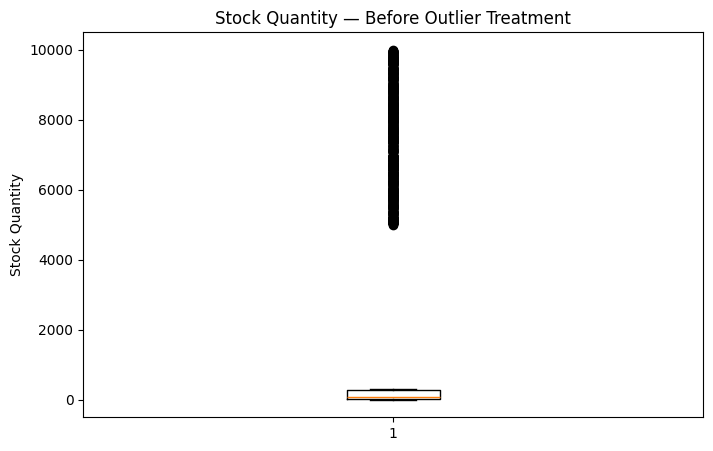

Stock quantity summary:


count    3000.000000
mean     1843.279000
std      3246.278383
min         0.000000
25%        30.000000
50%        73.000000
75%       282.250000
max      9997.000000
Name: Stock_Quantity, dtype: float64

In [20]:
# Visual inspection of stock quantity
plt.figure(figsize=(8, 5))
plt.boxplot(products["Stock_Quantity"].dropna())
plt.title("Stock Quantity — Before Outlier Treatment")
plt.ylabel("Stock Quantity")
plt.show()

print("Stock quantity summary:")
display(products["Stock_Quantity"].describe())


### Outlier treatment decision

The IQR rule flags a large portion of the stock values because the distribution is strongly right-skewed. Treating every IQR outlier as an error would remove or alter many potentially valid inventory quantities.

For this project, we therefore use **99th-percentile capping (winsorization)** rather than deleting rows:

- Values at or below the 99th percentile remain unchanged.
- Values above the 99th percentile are capped at the 99th-percentile value.
- No product rows are deleted.

This preserves the records while reducing the influence of extreme stock quantities in later analysis.


In [21]:
products_clean = products.copy()

upper_limit = products_clean["Stock_Quantity"].quantile(0.99)

products_clean["Stock_Quantity"] = products_clean["Stock_Quantity"].clip(
    upper=upper_limit
)

products_clean["Stock_Quantity"] = (
    products_clean["Stock_Quantity"]
    .round()
    .astype(int)
)

print(f"99th percentile cap: {upper_limit:.3f}")
print("\nStock quantity after treatment:")
display(products_clean["Stock_Quantity"].describe())


99th percentile cap: 9763.010

Stock quantity after treatment:


count    3000.000000
mean     1842.167333
std      3243.537682
min         0.000000
25%        30.000000
50%        73.000000
75%       282.250000
max      9763.000000
Name: Stock_Quantity, dtype: float64

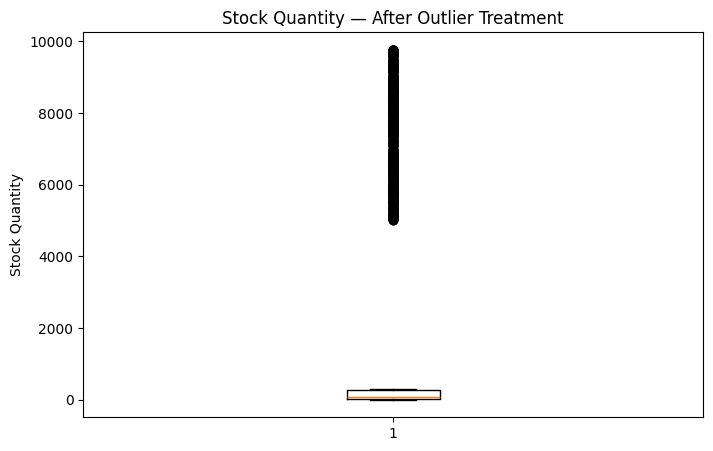

In [22]:
plt.figure(figsize=(8, 5))
plt.boxplot(products_clean["Stock_Quantity"].dropna())
plt.title("Stock Quantity — After Outlier Treatment")
plt.ylabel("Stock Quantity")
plt.show()


## 8. Final Data Quality Checks

Before exporting, we verify the main cleaned tables for:
- missing values,
- duplicate primary IDs,
- numeric data types,
- negative values where they should not exist,
- and basic row-count consistency.


In [23]:
def quality_report(df, key_column, numeric_columns=None):
    print(f"Rows: {len(df):,}")
    print(f"Columns: {len(df.columns):,}")
    print(f"Duplicate {key_column}: {df[key_column].duplicated().sum():,}")
    print("Total missing values:", int(df.isna().sum().sum()))

    if numeric_columns:
        print("\nNumeric checks:")
        for col in numeric_columns:
            if col in df.columns:
                print(
                    f"  {col}: dtype={df[col].dtype}, "
                    f"negative={(df[col] < 0).sum():,}"
                )

print("CUSTOMERS")
quality_report(customers, "Customer_ID")

print("\nEMPLOYEES")
quality_report(employees, "Employee_ID", ["Salary"])

print("\nPRODUCTS")
quality_report(products_clean, "Product_ID", ["Price", "Stock_Quantity"])

print("\nORDERS")
quality_report(df_orders, "Order_ID", ["Total_Amount"])




CUSTOMERS
Rows: 3,000
Columns: 7
Duplicate Customer_ID: 0
Total missing values: 0

EMPLOYEES
Rows: 3,000
Columns: 8
Duplicate Employee_ID: 0
Total missing values: 0

Numeric checks:
  Salary: dtype=int64, negative=0

PRODUCTS
Rows: 3,000
Columns: 6
Duplicate Product_ID: 0
Total missing values: 0

Numeric checks:
  Price: dtype=int64, negative=0
  Stock_Quantity: dtype=int64, negative=0

ORDERS
Rows: 3,000
Columns: 8
Duplicate Order_ID: 0
Total missing values: 0

Numeric checks:
  Total_Amount: dtype=int64, negative=0


## 9. Export the Cleaned Dataset

The cleaned tables are written back to the project workbook.

### Final cleaned outputs
- `online_shopping_db_order_items` → includes `Total_Amount`
- `online_shopping_db_orders` → includes order-level `Total_Amount`
- `Clean_online_shopping_db_custom` → cleaned customer Email & Gender
- `online_shopping_db_employees` → cleaned Email, Salary & Gender
- `Clean_online_shopping_db_produc` → cleaned Price & treated Stock Quantity

The remaining source sheets are preserved because they were not modified in this cleaning notebook.


In [ ]:
with pd.ExcelWriter(
    "Clean_Project.xlsx",
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    df_order_items.to_excel(
        writer,
        sheet_name="online_shopping_db_order_items",
        index=False
    )

    df_orders.to_excel(
        writer,
        sheet_name="online_shopping_db_orders",
        index=False
    )

    customers.to_excel(
        writer,
        sheet_name="Clean_online_shopping_db_custom",
        index=False
    )

    employees.to_excel(
        writer,
        sheet_name="online_shopping_db_employees",
        index=False
    )

    products_clean.to_excel(
        writer,
        sheet_name="Clean_online_shopping_db_produc",
        index=False
    )

print("✅ Cleaned tables exported successfully to Clean_Project.xlsx")


#  Cleaning Complete

The workbook is now prepared for the next project stage.

### Main transformations completed
| Table | Main cleaning / transformation |
|---|---|
| Customers | Email standardization + Gender cleaning |
| Employees | Email + Salary + Gender cleaning |
| Order Items | Calculated `Total_Amount` |
| Orders | Added aggregated order-level `Total_Amount` |
| Products | Price standardization + Stock Quantity outlier treatment |

**Next stage:** import the cleaned workbook/tables into SQL and continue with database analysis and queries.
